<a href="https://colab.research.google.com/github/RaniaChaudhry511/SUPERWISED-MACHINE-LEARING-MODEL/blob/main/XG_Boost_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                           XG BOOST (ALGORITHM) PROJECT

                                                "HR Employee Attrition Prediction Using XGBoost Algorithm"


                                                     STEP 1 DATA LOADING AND UNDERSTANDING

In [ ]:
# ── Core Libraries ──────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ───────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ── Preprocessing ───────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.pipeline       import Pipeline

# ── XGBoost ─────────────────────────────────────
from xgboost import XGBClassifier, plot_importance

# ── Evaluation Metrics ──────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, f1_score
)

# ── Hyperparameter Tuning ───────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── Class Imbalance (optional) ──────────────────
from imblearn.over_sampling import SMOTE

df=pd.read_csv("/content/HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


                                                              STEP 2 DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Numerical Columns:

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

================ OUTLIERS CHECK ================

Age
Outliers: 0
----------------------------------------
DailyRate
Outliers: 0
----------------------------------------
DistanceFromHome
Outliers: 0
----------------------------------------
Education
Outliers: 0
----------------------------------------
EmployeeCount
Outliers: 0
----------------------------------------
EmployeeNumber
Outliers: 0
--------

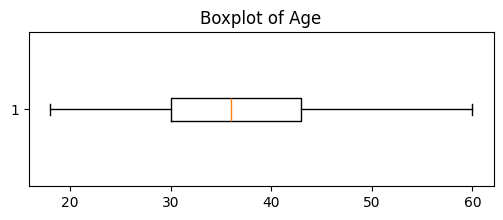

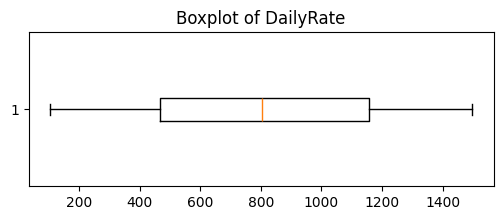

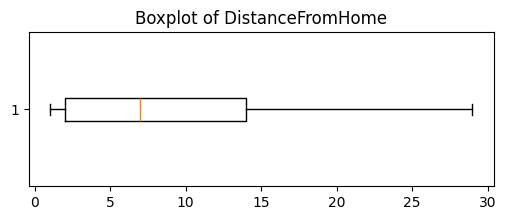

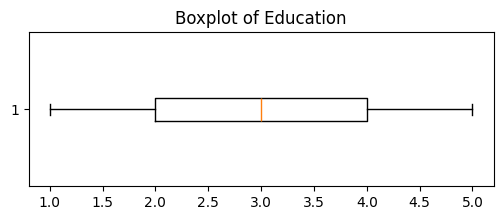

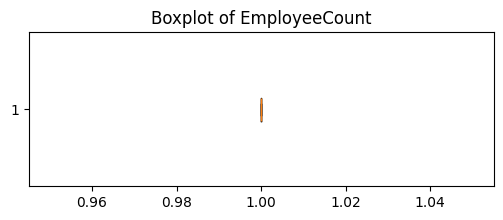

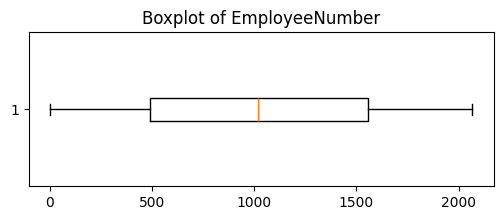

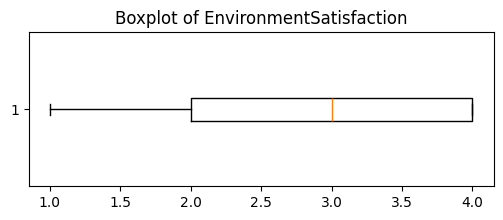

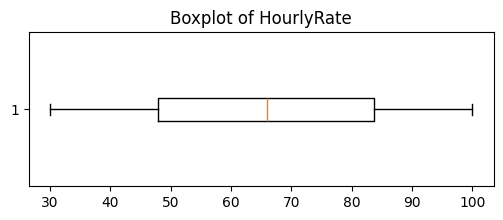

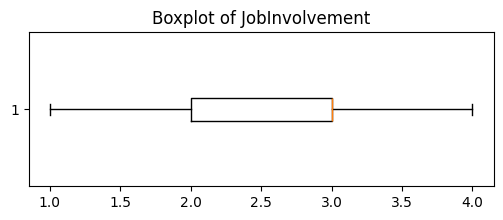

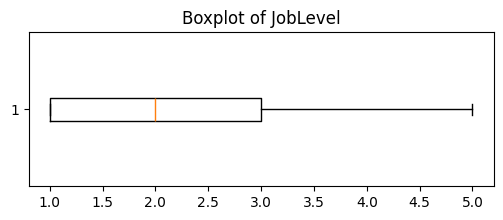

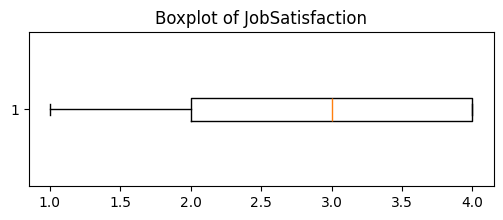

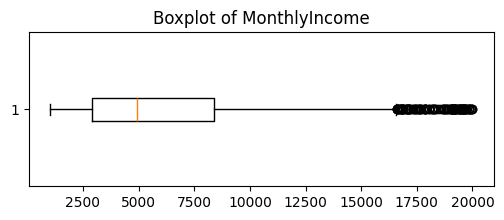

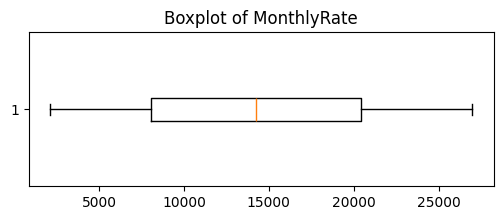

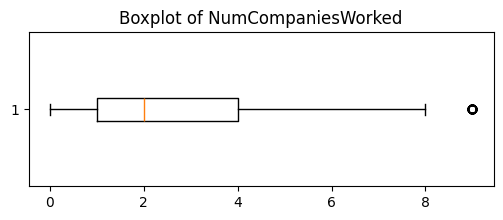

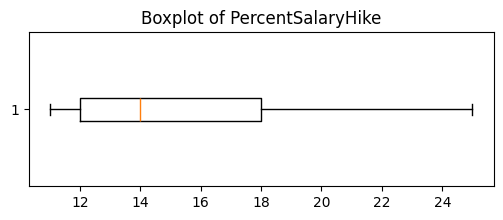

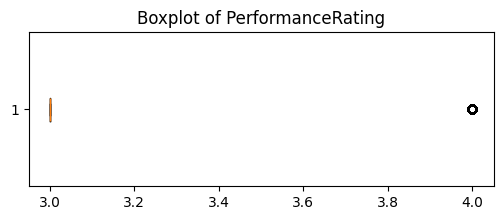

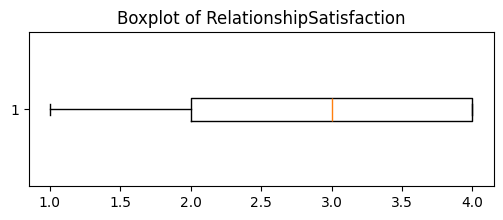

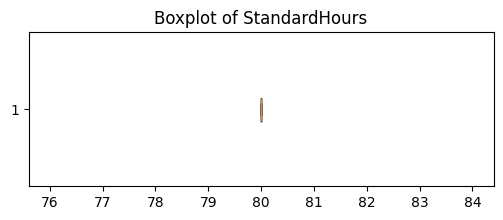

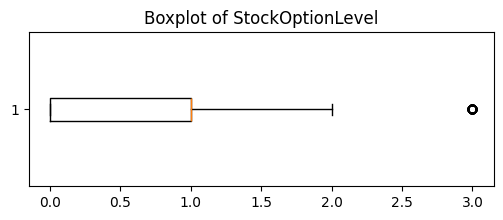

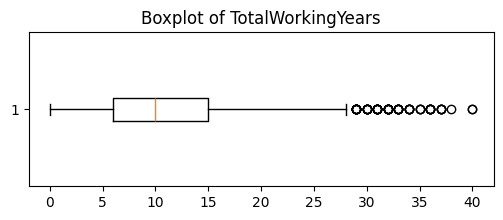

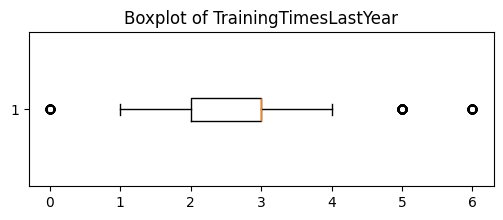

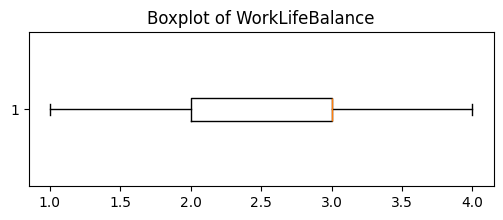

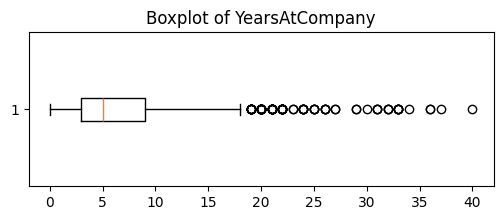

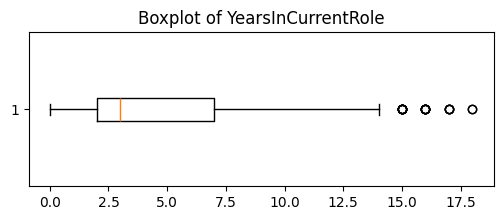

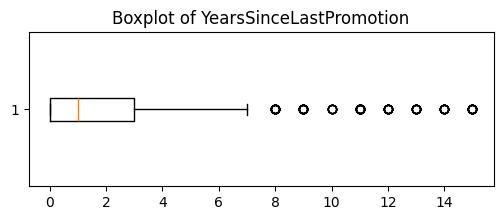

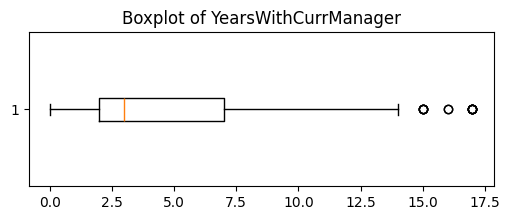

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset load karo
df = pd.read_csv("HR-Employee-Attrition.csv")

# Sirf numerical columns
num_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:\n")
print(num_cols)

print("\n================ OUTLIERS CHECK ================\n")

# IQR Method
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Outliers: {len(outliers)}")
    print("-" * 40)

# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

Outliers were checked in the dataset using the IQR (Interquartile Range) method. Most numerical features did not contain significant outliers. However, some columns such as MonthlyIncome, TotalWorkingYears, YearsAtCompany, and YearsSinceLastPromotion showed a noticeable number of outliers. These values may represent employees with very high salaries or long work experience, so they are not necessarily errors.

Some discrete columns like PerformanceRating, StockOptionLevel, and TrainingTimesLastYear also showed outliers, but since these columns contain limited integer categories, the IQR method may identify normal values as outliers. Therefore, these features should be handled carefully.

Since XGBoost is a robust machine learning algorithm that can handle outliers effectively, removing all outliers was not considered necessary. Only important continuous features may require cleaning if extreme values negatively affect model performance.


In [ ]:
cols_to_clean = [
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsSinceLastPromotion'
]

In [ ]:
for col in cols_to_clean:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("New Shape:", df.shape)

New Shape: (1127, 35)


After removing outliers from selected continuous features using the IQR method, the dataset size changed from 1470 rows to 1127 rows. This preprocessing step helped reduce the impact of extreme values and improved the overall data quality for training the XGBoost model.


                                                               STEP 3 EDA

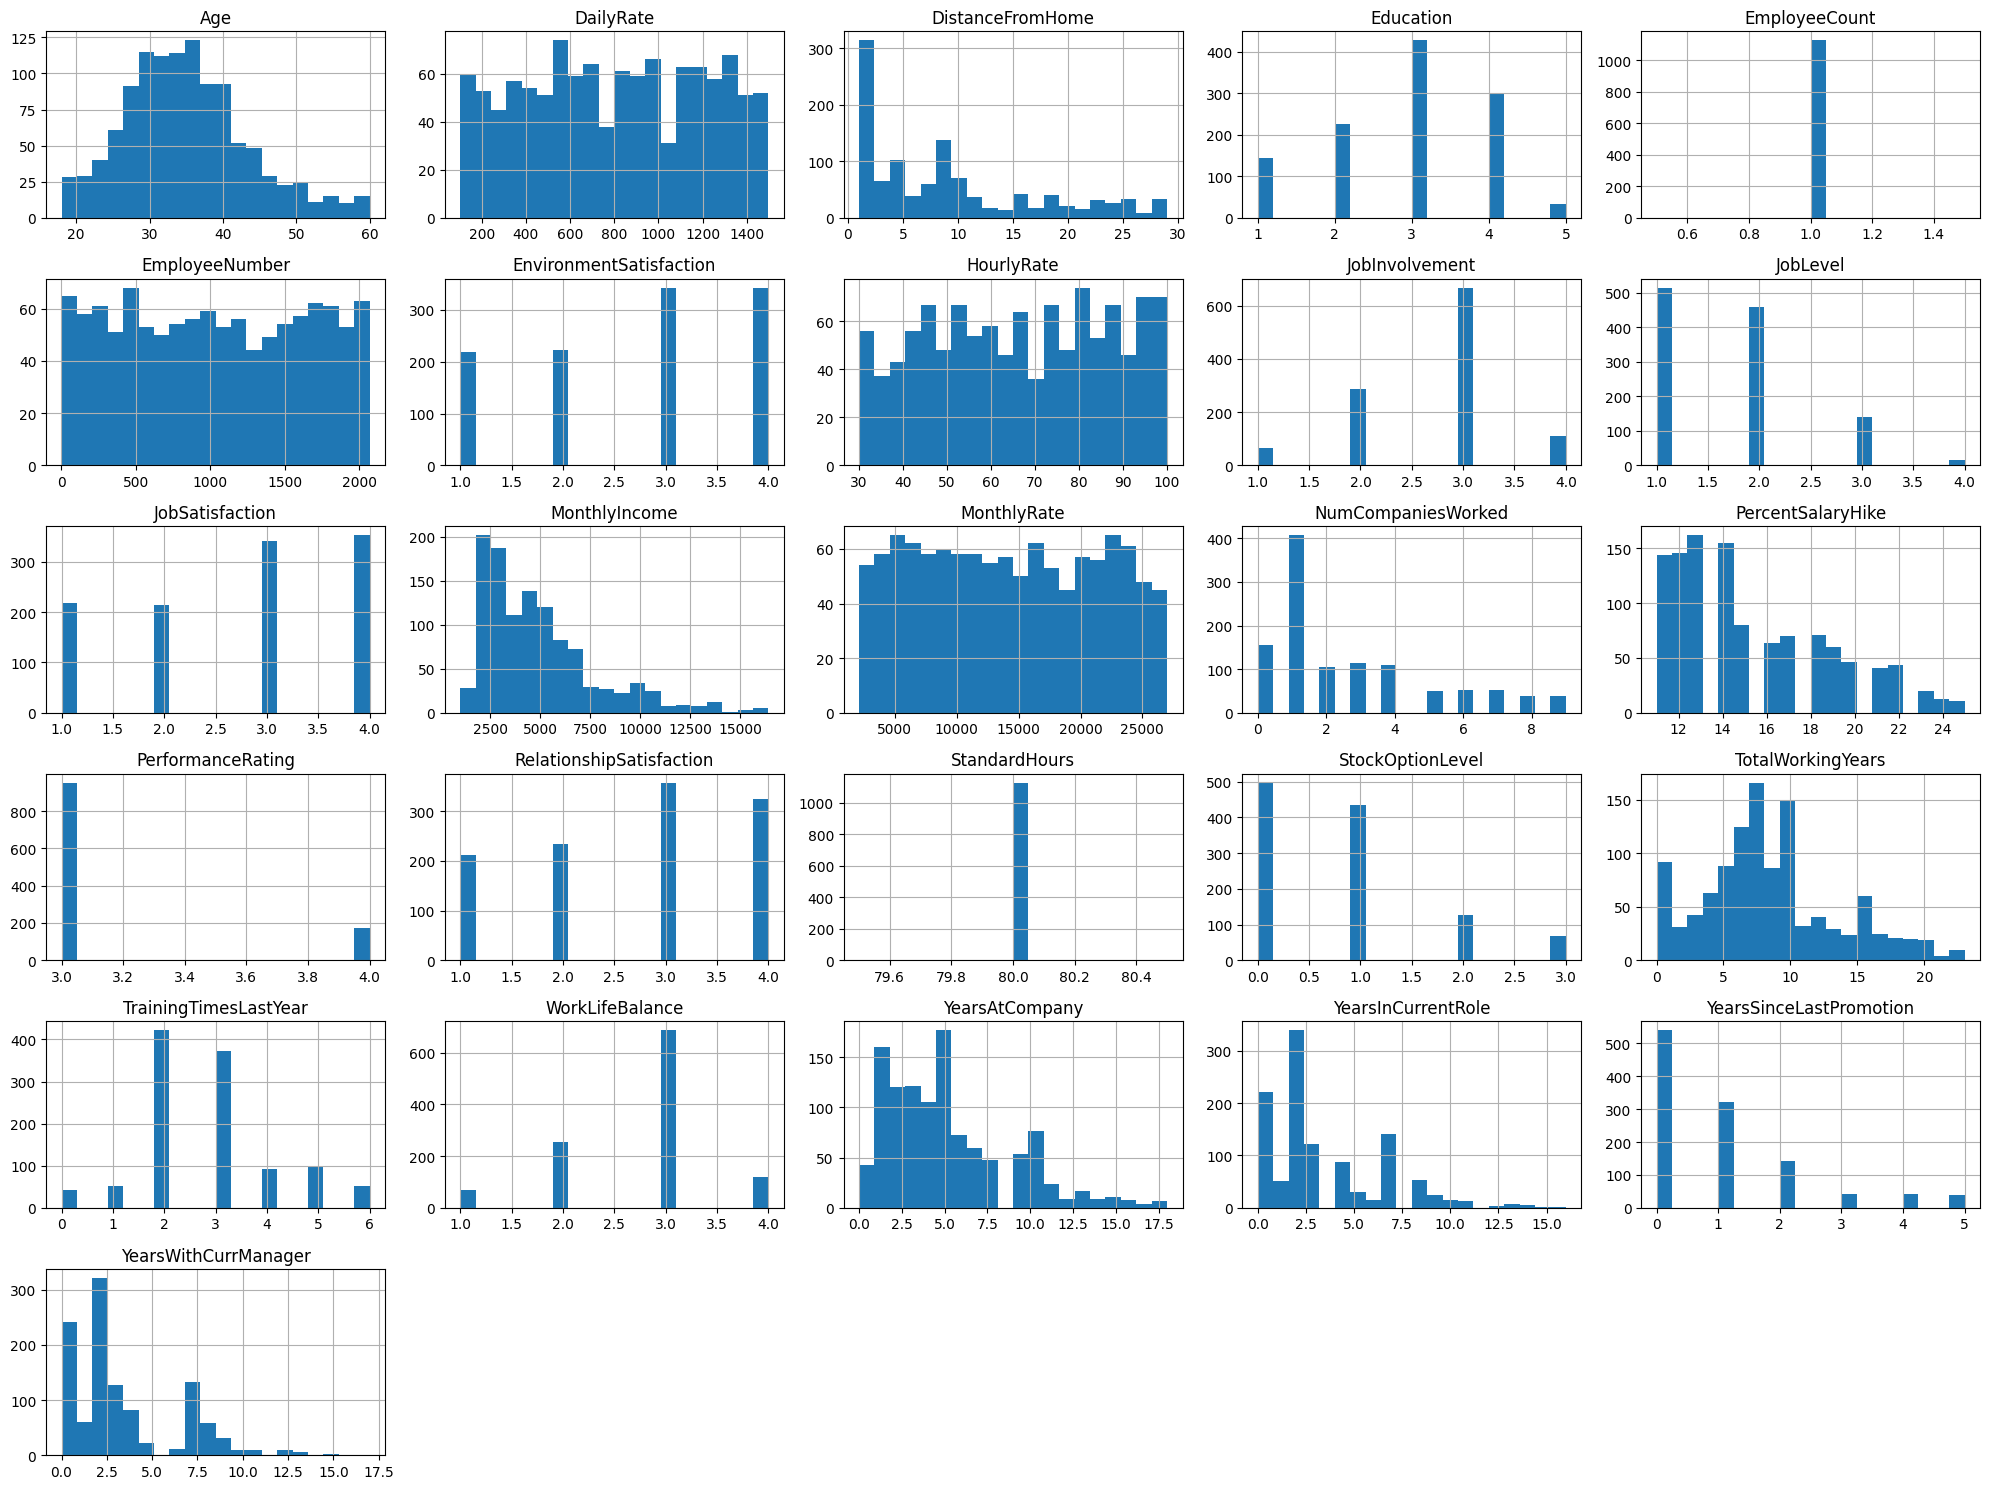

In [ ]:
import matplotlib.pyplot as plt

# Numerical columns ka histogram
df.hist(figsize=(20,15), bins=20)

plt.tight_layout()
plt.show()

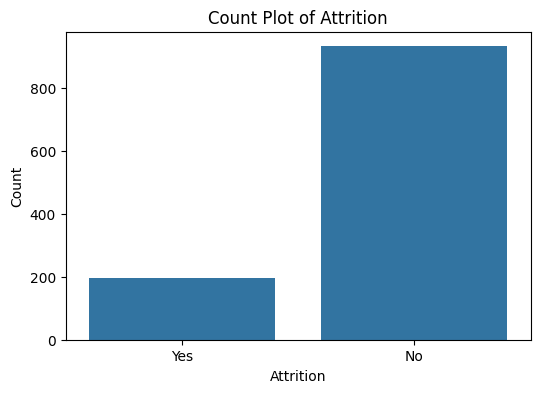

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Attrition', data=df)

plt.title('Count Plot of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')

plt.show()

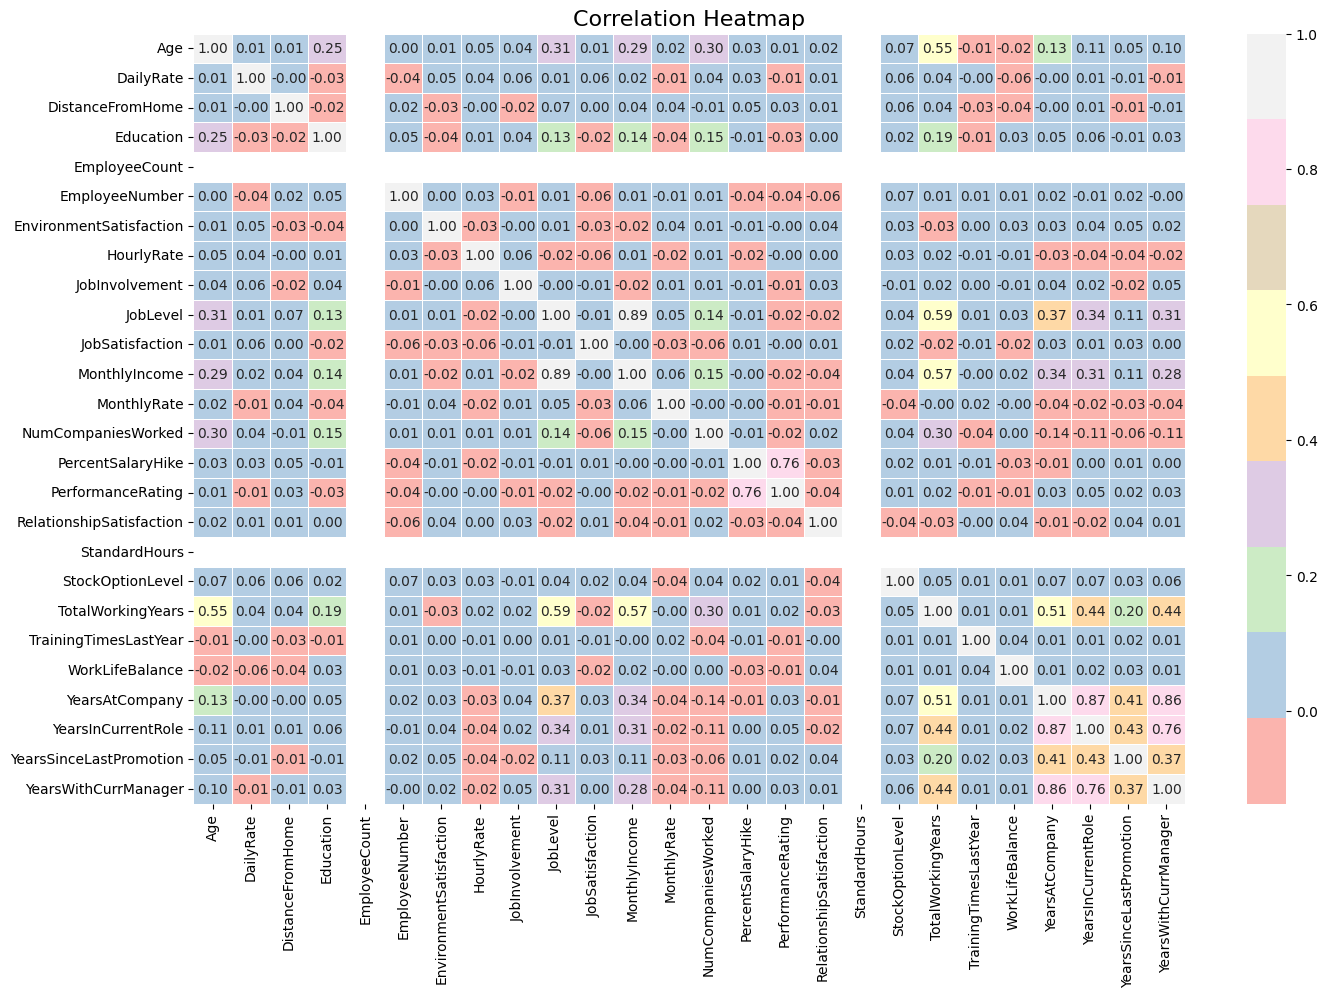

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation = df.corr(numeric_only=True)

# Figure size
plt.figure(figsize=(16,10))

# Heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Pastel1",
    linewidths=0.5
)

# Title
plt.title("Correlation Heatmap", fontsize=16)

# Show plot
plt.show()

                                                               STEP 4 FEATURE ENGINEERING

In [ ]:
# target encoding
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# one-hot encoding for all categorical columns
df = pd.get_dummies(df, drop_first=True)

# ensure ML-ready numeric format
df = df.astype(int)

In [ ]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,1,2,3,61,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,1,4,4,92,2,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,1,5,4,56,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,7,1,40,3,...,1,0,0,0,0,0,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

XGBoost is a tree-based machine learning model, and it does not need feature scaling. This is because decision trees work by splitting data based on conditions (like greater than or less than a value), not on distances between values. So, the size or range of features does not affect how the model makes decisions.

However, feature scaling is still optional and does not harm the XGBoost model. It is mainly useful when you are using different types of algorithms together in the same project.

                                                              STEP 5 TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

                                                           STEP 6 MODEL TRAINING AND SELECTION

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

                                                        STEP 7 MODEL PREDICTION

In [ ]:
# predictions
y_pred = model.predict(X_test)

# first 10 predictions check
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


ACTUAL VS PREDICTED

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(10))

      Actual  Predicted
1426       0          0
1417       0          0
980        1          0
176        0          0
1337       0          0
682        0          0
1070       0          0
628        0          0
1461       1          0
1255       1          1


                                                         STEP 8 MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# full report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8539823008849557

Confusion Matrix:
 [[183   3]
 [ 30  10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92       186
           1       0.77      0.25      0.38        40

    accuracy                           0.85       226
   macro avg       0.81      0.62      0.65       226
weighted avg       0.84      0.85      0.82       226



The model achieved 85% accuracy, but performance on the minority class (Attrition = Yes) is weak, indicating class imbalance issues. The model is biased towards predicting non-attrition cases.”

                                                            STEP 9 MODEL TUNING

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# base model
xgb = XGBClassifier(eval_metric='logloss')

# parameters grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

# grid search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Tuned Accuracy: 0.8495575221238938


“After hyperparameter tuning using GridSearchCV, the model achieved similar performance with slightly reduced accuracy, indicating that the default model was already near optimal and not heavily overfitting.”

                                                          STEP 10 CROSS VALIDATION

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

model = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    eval_metric='logloss'
)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.84955752 0.86725664 0.87111111 0.85777778 0.85777778]
Mean Accuracy: 0.8606961651917404


Cross-validation results show an average accuracy of approximately 86%, indicating that the model is stable and generalizes well across different data splits.”

                                                              STEP 11 PIPELINE BUILDING

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),   # feature scaling
    ("model", XGBClassifier(
        learning_rate=0.1,
        max_depth=3,
        n_estimators=100,
        eval_metric="logloss",
        random_state=42
    ))
])

# training
pipeline.fit(X_train, y_train)

# prediction
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Pipeline Accuracy:", accuracy_score(y_test, y_pred))

Pipeline Accuracy: 0.8495575221238938


“A machine learning pipeline was built using StandardScaler and XGBoost classifier to ensure a clean and leak-free workflow. The final pipeline achieved an accuracy of approximately 85%, confirming consistent performance.”

                                                            STEP 12   FINA CONCLUSION

In this project, a machine learning model was developed to predict employee attrition using an HR dataset. The workflow included data preprocessing, encoding of categorical variables, feature scaling, exploratory data analysis, and model training using the XGBoost algorithm.

The model was evaluated using a train-test split, cross-validation, and hyperparameter tuning. It achieved an accuracy of approximately 85%, with consistent performance across cross-validation folds (mean accuracy ≈ 86%), indicating that the model is stable and generalizes well on unseen data.

However, the evaluation also showed that the model performs better on non-attrition cases compared to attrition cases, mainly due to class imbalance in the dataset. This highlights that in real-world HR problems, accuracy alone is not the most important metric; recall and correct identification of employees at risk of leaving are more critical.

Overall, the project successfully demonstrates the end-to-end machine learning pipeline and shows how XGBoost can be applied effectively for classification problems in HR analytics, while also emphasizing the importance of data quality and class balance in improving model performance.